# 📊 Statistical Analysis: Environmental Inequality in the ZMVM

**Cross-variable correlations, integrated burden, and data export for dashboard**

*Notebook 7 of 8 · Project: Dos Méxicos Bajo el Mismo Sol*  
*Author: Nelly Itzel Rodríguez Ortiz · Last updated: July 2026*

---

**What this notebook does:**

1. Loads and merges AGEB-level (social/health) and municipio-level (environmental) data
2. Computes cross-correlations between all 7 key variables
3. Quantifies the environmental divide by zone (Norte, Centro, Sur)
4. Builds an Integrated Burden Score ranking each municipio
5. Exports clean CSV datasets for the Streamlit dashboard


## ⚙️ Setup and data loading

In [1]:
from __future__ import annotations
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Paths — project root (works from notebooks/ too)
_cwd = Path.cwd()
ROOT = _cwd if (_cwd / "data").exists() else _cwd.parent
PROCESSED = ROOT / "data" / "processed"
OUTPUTS = ROOT / "outputs" / "graficos"
EXPORT = ROOT / "dashboards" / "data"

OUTPUTS.mkdir(parents=True, exist_ok=True)
EXPORT.mkdir(parents=True, exist_ok=True)

# Zone definitions — balanced 7-7-7 by municipio centroid latitude
# Derived from INEGI municipio polygons (09mun + 15mun), centroids in EPSG:6372,
# split into terciles: lowest 7 = Sur, middle 7 = Centro, highest 7 = Norte
ZONAS = {
    'Norte': ['Venustiano Carranza','Naucalpan de Juárez','Azcapotzalco',
              'Gustavo A. Madero','Tlalnepantla de Baz','Ecatepec de Morelos',
              'Coacalco de Berriozábal'],
    'Centro': ['Álvaro Obregón','Iztapalapa','Benito Juárez','Iztacalco',
               'Nezahualcóyotl','Miguel Hidalgo','Cuauhtémoc'],
    'Sur': ['Milpa Alta','Tlalpan','Xochimilco','La Magdalena Contreras',
            'Tláhuac','Cuajimalpa de Morelos','Coyoacán'],
}

# Zone colours
COLORS = {'Norte': '#E74C3C', 'Centro': '#F39C12', 'Sur': '#27AE60'}

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

print('✓ Setup complete')


✓ Setup complete


In [2]:
# Additional imports for regression, clustering, and hypothesis testing
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import statsmodels.api as sm
from scipy.stats import f_oneway, pearsonr


### 1.1 Load AGEB master and filter to study area

In [3]:
# Load data
master = pd.read_csv(PROCESSED / 'master_ageb_zmvm.csv')
mun_env = pd.read_csv(PROCESSED / 'municipio_indicators.csv')

# Filter to 20 study municipios
aoi_muns = mun_env['NOM_MUN'].tolist()
ageb = master[master['NOM_MUN'].isin(aoi_muns)].copy()

print(f'AGEBs total: {len(master):,}')
print(f'AGEBs en AOI: {len(ageb):,}')
print(f'Municipios: {len(aoi_muns)}')


AGEBs total: 6,805
AGEBs en AOI: 3,419
Municipios: 21


### 1.2 Assign zones and aggregate to municipio level

In [4]:
def assign_zone(mun_name: str) -> str:
    for zone, muns in ZONAS.items():
        if mun_name in muns:
            return zone
    return 'Sur'

ageb['zona'] = ageb['NOM_MUN'].apply(assign_zone)

# Aggregate AGEB data to municipio level
mun_social = ageb.groupby('NOM_MUN').agg(
    n_agebs=('IM_2020', 'count'),
    imn_mean=('IMN_2020', 'mean'),
    imn_std=('IMN_2020', 'std'),
    poblacion=('POB_TOTAL', 'sum'),
    egresos_total=('egresos_resp', 'sum'),
    area_verde_total_m2=('area_verde_total_m2', 'sum'),
).reset_index()

# Respiratory rate per 100,000
mun_social['tasa_respiratoria'] = (
    mun_social['egresos_total'] / mun_social['poblacion'] * 100_000
)

# Merge with environmental data
merged = mun_social.merge(mun_env, on='NOM_MUN', how='inner')
merged['zona'] = merged['NOM_MUN'].apply(assign_zone)

print(f'Dataset merged: {len(merged)} municipios')
print(merged[['NOM_MUN','zona','lst_mean','ndvi_mean','imn_mean',
              'tasa_respiratoria']].round(3).head(10).to_string(index=False))


Dataset merged: 21 municipios
                NOM_MUN   zona  lst_mean  ndvi_mean  imn_mean  tasa_respiratoria
           Azcapotzalco  Norte    39.047      0.089     0.961           7740.789
          Benito Juárez Centro    36.674      0.098     0.972           2607.836
Coacalco de Berriozábal  Norte    32.961      0.209     0.959           1694.147
               Coyoacán    Sur    34.601      0.138     0.966          10317.777
  Cuajimalpa de Morelos    Sur    22.963      0.247     0.952           2433.544
             Cuauhtémoc Centro    38.219      0.083     0.959          13755.908
    Ecatepec de Morelos  Norte    36.567      0.135     0.940          25574.261
      Gustavo A. Madero  Norte    36.112      0.125     0.955          24048.488
              Iztacalco Centro    38.973      0.079     0.958           6716.007
             Iztapalapa Centro    36.597      0.105     0.946          32362.416


## 2. Descriptive Statistics by Zone

In [5]:
var_desc = ['lst_mean','ndvi_mean','no2_mean','pm25_mean',
             'imn_mean','tasa_respiratoria','area_verde_total_m2']

desc_labels = {
    'lst_mean': 'LST media (°C)', 'ndvi_mean': 'NDVI medio',
    'no2_mean': 'NO₂ medio (mol/m²)', 'pm25_mean': 'PM₂.₅ medio (µg/m³)',
    'imn_mean': 'IMN medio', 'tasa_respiratoria': 'Tasa resp. (×100k)',
    'area_verde_total_m2': 'Área verde total (m²)',
}

print('=== ESTADÍSTICAS POR ZONA ===')
for z in ['Norte','Centro','Sur']:
    sub = merged[merged['zona'] == z]
    print(f"\n--- {z} ({len(sub)} municipios) ---")
    for v in var_desc:
        vals = sub[v].dropna()
        if len(vals) > 0:
            print(f'  {desc_labels.get(v, v):30s}: {vals.mean():>10.3f} \u00b1 {vals.std():.3f}')


=== ESTADÍSTICAS POR ZONA ===

--- Norte (7 municipios) ---
  LST media (°C)                :     35.877 ± 3.280
  NDVI medio                    :      0.144 ± 0.052
  NO₂ medio (mol/m²)            :      0.000 ± 0.000
  PM₂.₅ medio (µg/m³)           :     18.932 ± 1.755
  IMN medio                     :      0.953 ± 0.007
  Tasa resp. (×100k)            :  12735.992 ± 8793.121
  Área verde total (m²)         : 5073530.020 ± 7205356.075

--- Centro (7 municipios) ---
  LST media (°C)                :     36.105 ± 3.605
  NDVI medio                    :      0.115 ± 0.045
  NO₂ medio (mol/m²)            :      0.000 ± 0.000
  PM₂.₅ medio (µg/m³)           :     17.857 ± 1.828
  IMN medio                     :      0.958 ± 0.011
  Tasa resp. (×100k)            :  12614.797 ± 9829.237
  Área verde total (m²)         : 6515412.721 ± 5516051.306

--- Sur (7 municipios) ---
  LST media (°C)                :     26.676 ± 4.809
  NDVI medio                    :      0.239 ± 0.046
  NO₂ medio (

## 2.1. Boxplots by Zone

Visual distribution of each key variable across Norte, Centro, Sur.

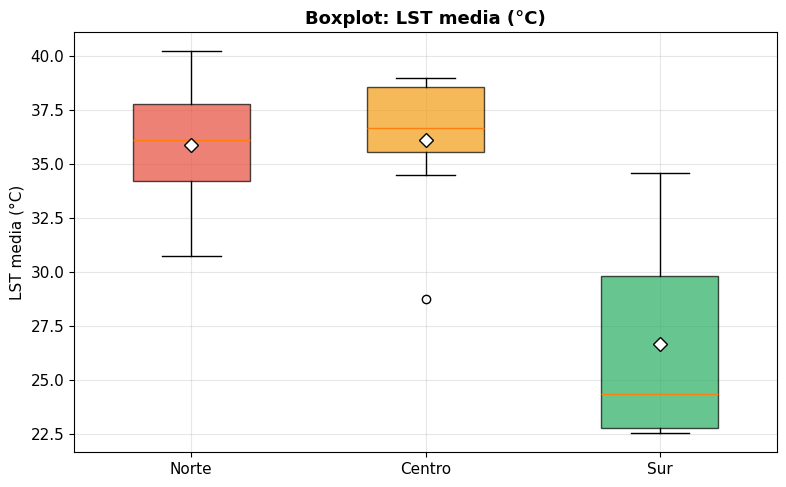

✓ Saved boxplot_lst_mean.png


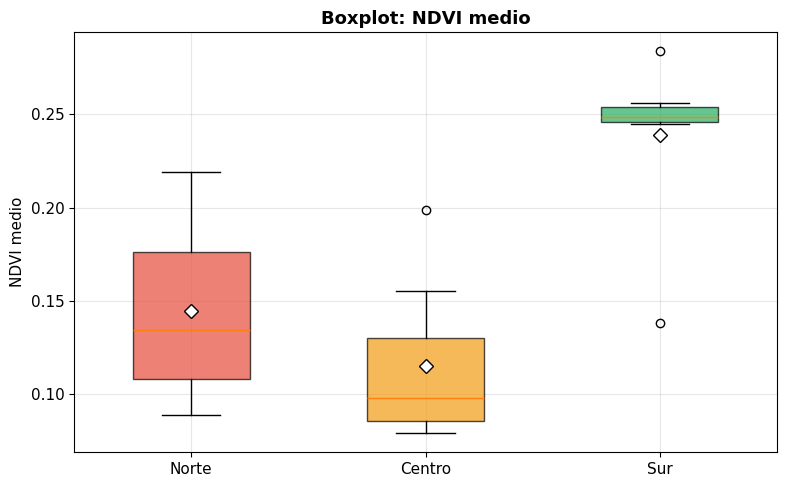

✓ Saved boxplot_ndvi_mean.png


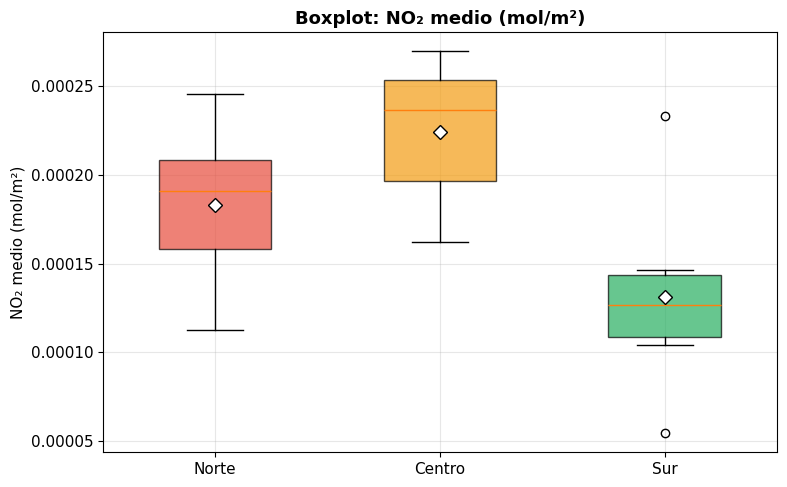

✓ Saved boxplot_no2_mean.png


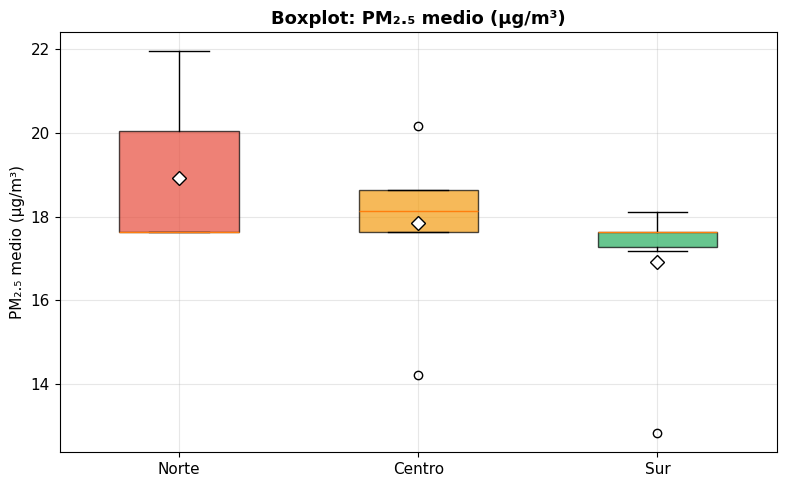

✓ Saved boxplot_pm25_mean.png


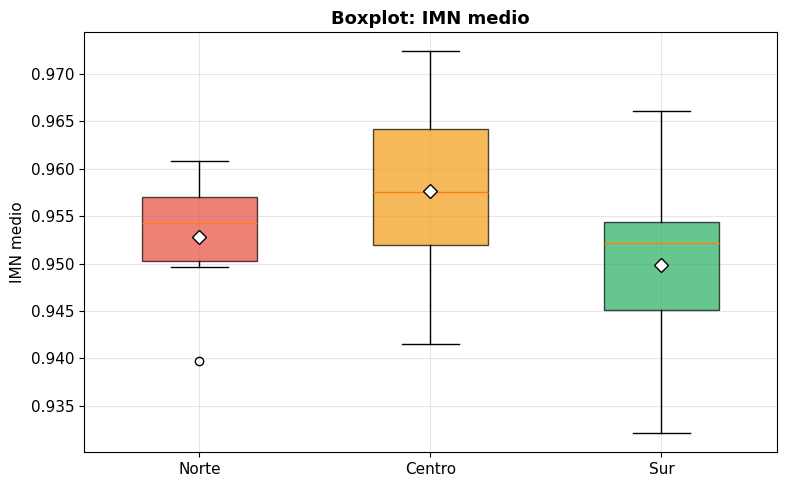

✓ Saved boxplot_imn_mean.png


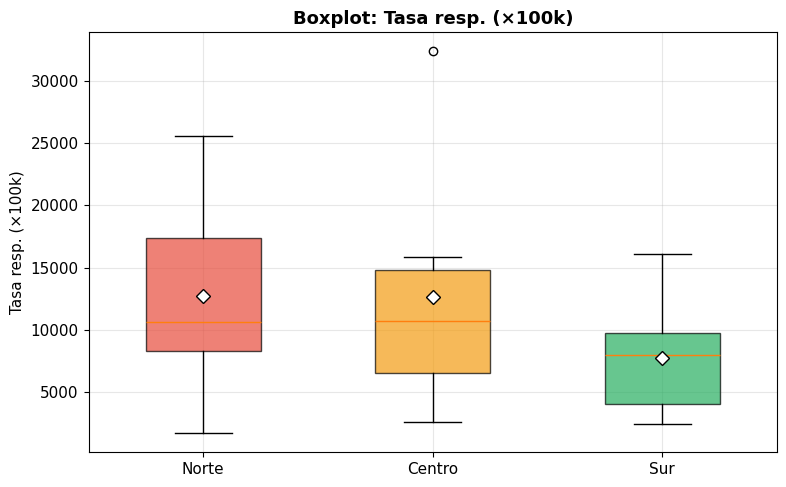

✓ Saved boxplot_tasa_respiratoria.png


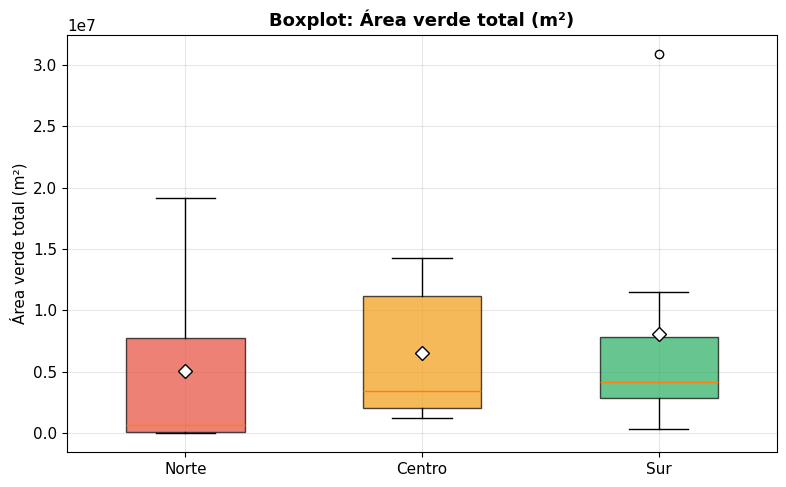

✓ Saved boxplot_area_verde_total_m2.png


In [6]:
# Boxplots for each key variable grouped by zone
boxplot_vars = ['lst_mean','ndvi_mean','no2_mean','pm25_mean',
                'imn_mean','tasa_respiratoria','area_verde_total_m2']
boxplot_labels = {
    'lst_mean': 'LST media (°C)',
    'ndvi_mean': 'NDVI medio',
    'no2_mean': 'NO₂ medio (mol/m²)',
    'pm25_mean': 'PM₂.₅ medio (µg/m³)',
    'imn_mean': 'IMN medio',
    'tasa_respiratoria': 'Tasa resp. (×100k)',
    'area_verde_total_m2': 'Área verde total (m²)',
}
bp_colors = [COLORS[z] for z in ['Norte','Centro','Sur']]

for var in boxplot_vars:
    fig, ax = plt.subplots(figsize=(8, 5))
    data = [merged[merged['zona']==z][var].dropna().values
            for z in ['Norte','Centro','Sur']]
    bp = ax.boxplot(data, labels=['Norte','Centro','Sur'],
                    patch_artist=True, widths=0.5, showmeans=True,
                    meanprops=dict(marker='D', markerfacecolor='white',
                                   markeredgecolor='black', markersize=7))
    for patch, color in zip(bp['boxes'], bp_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(f'Boxplot: {boxplot_labels[var]}', fontsize=13, fontweight='bold')
    ax.set_ylabel(boxplot_labels[var])
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUTS / f'boxplot_{var}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✓ Saved boxplot_{var}.png')


## 3. Cross-Correlation Analysis

In [7]:
corr_vars = ['lst_mean','ndvi_mean','no2_mean','pm25_mean',
             'imn_mean','tasa_respiratoria','area_verde_total_m2']

corr_labels = {
    'lst_mean': 'LST', 'ndvi_mean': 'NDVI', 'no2_mean': 'NO₂',
    'pm25_mean': 'PM₂.₅', 'imn_mean': 'IMN',
    'tasa_respiratoria': 'Tasa resp.', 'area_verde_total_m2': 'Área verde',
}

# Pearson correlation
corr_matrix = merged[corr_vars].corr(method='pearson')

# p-values matrix (using .iloc[:, j] to avoid DataFrame-from-DataFrame on diagonal)
def pearson_pvals(df):
    cols = df.columns
    pvals = pd.DataFrame(np.ones((len(cols), len(cols))), index=cols, columns=cols)
    for i, c1 in enumerate(cols):
        for j, c2 in enumerate(cols):
            x = df.iloc[:, i]
            y = df.iloc[:, j]
            mask = ~(x.isna() | y.isna())
            if mask.sum() > 2:
                _, p = stats.pearsonr(x[mask], y[mask])
                pvals.iloc[i, j] = p
    return pvals

pvals = pearson_pvals(merged[corr_vars])

print('=== MATRIZ DE CORRELACIÓN ===')
print(corr_matrix.round(3))

print('\n=== P-VALUES ===')
print(pvals.round(4))

print('\n=== CORRELACIONES SIGNIFICATIVAS (p < 0.05) ===')
for i, v1 in enumerate(corr_vars):
    for j, v2 in enumerate(corr_vars):
        if i < j:
            r = corr_matrix.loc[v1, v2]
            p = pvals.loc[v1, v2]
            if p < 0.05:
                sig = "***" if p < 0.001 else "**" if p < 0.01 else "*"
                print(f'  {corr_labels[v1]:15s} \u2194 {corr_labels[v2]:15s}: r = {r:+.3f}  p = {p:.4f}  {sig}')


=== MATRIZ DE CORRELACIÓN ===
                     lst_mean  ndvi_mean  no2_mean  pm25_mean  imn_mean  \
lst_mean                1.000     -0.936     0.689      0.503     0.296   
ndvi_mean              -0.936      1.000    -0.790     -0.480    -0.372   
no2_mean                0.689     -0.790     1.000      0.290     0.741   
pm25_mean               0.503     -0.480     0.290      1.000    -0.020   
imn_mean                0.296     -0.372     0.741     -0.020     1.000   
tasa_respiratoria       0.287     -0.301     0.035      0.162    -0.287   
area_verde_total_m2    -0.062     -0.029     0.039     -0.266     0.149   

                     tasa_respiratoria  area_verde_total_m2  
lst_mean                         0.287               -0.062  
ndvi_mean                       -0.301               -0.029  
no2_mean                         0.035                0.039  
pm25_mean                        0.162               -0.266  
imn_mean                        -0.287                0.149

### 3.1 Correlation heatmap

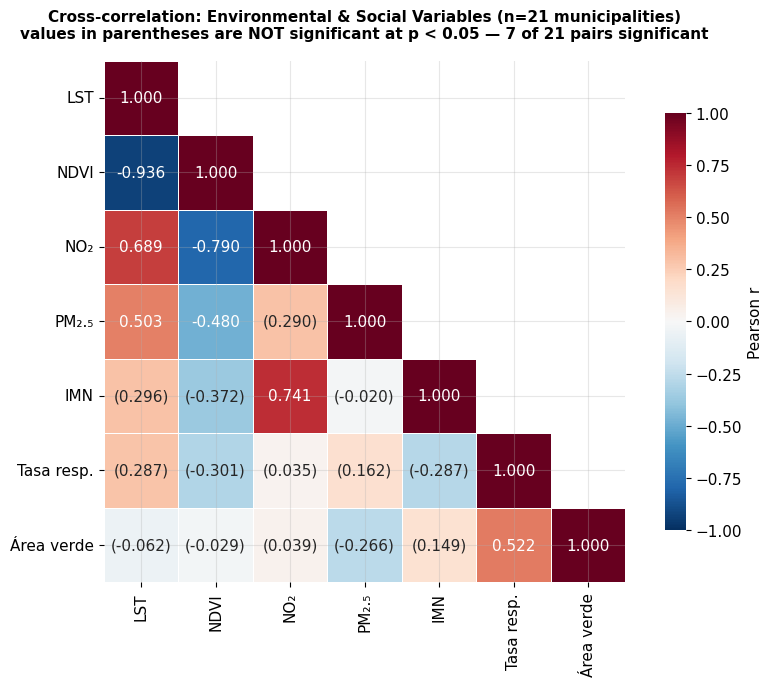

✓ Saved heatmap (n=21 municipalities, 7/21 pairs significant)


In [8]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

# `pvals` was computed in the previous cell, from the actual observations with
# stats.pearsonr. Reuse it: n_obs here is the number of MUNICIPALITIES, not the
# number of variables in corr_matrix.
n_obs = len(merged)
r_lab = corr_matrix.rename(columns=corr_labels, index=corr_labels)
p_lab = (pvals.rename(columns=corr_labels, index=corr_labels)
         .reindex(index=r_lab.index, columns=r_lab.columns))

# Correlations that are NOT significant at p < 0.05 are shown in parentheses:
# with only this many municipalities most pairs cannot be distinguished from zero.
annot = pd.DataFrame(
    [[f"{v:.3f}" if p < 0.05 else f"({v:.3f})"
      for v, p in zip(row_r, row_p)]
     for row_r, row_p in zip(r_lab.values, p_lab.values)],
    index=r_lab.index, columns=r_lab.columns,
)

sns.heatmap(
    r_lab, mask=mask, annot=annot, fmt='', cmap='RdBu_r',
    vmin=-1, vmax=1, center=0, square=True,
    linewidths=0.5, cbar_kws={'shrink': 0.8, 'label': 'Pearson r'},
    ax=ax,
)
n_pairs = len(r_lab) * (len(r_lab) - 1) // 2
n_sig = int(((p_lab.values < 0.05).sum() - len(r_lab)) / 2)
ax.set_title(
    f'Cross-correlation: Environmental & Social Variables (n={n_obs} municipalities)\n'
    f'values in parentheses are NOT significant at p < 0.05 '
    f'\u2014 {n_sig} of {n_pairs} pairs significant',
    fontsize=11, fontweight='bold', pad=16)
plt.tight_layout()
plt.savefig(OUTPUTS / 'correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\u2713 Saved heatmap (n={n_obs} municipalities, {n_sig}/{n_pairs} pairs significant)')


## 4. Key Regressions by Zone

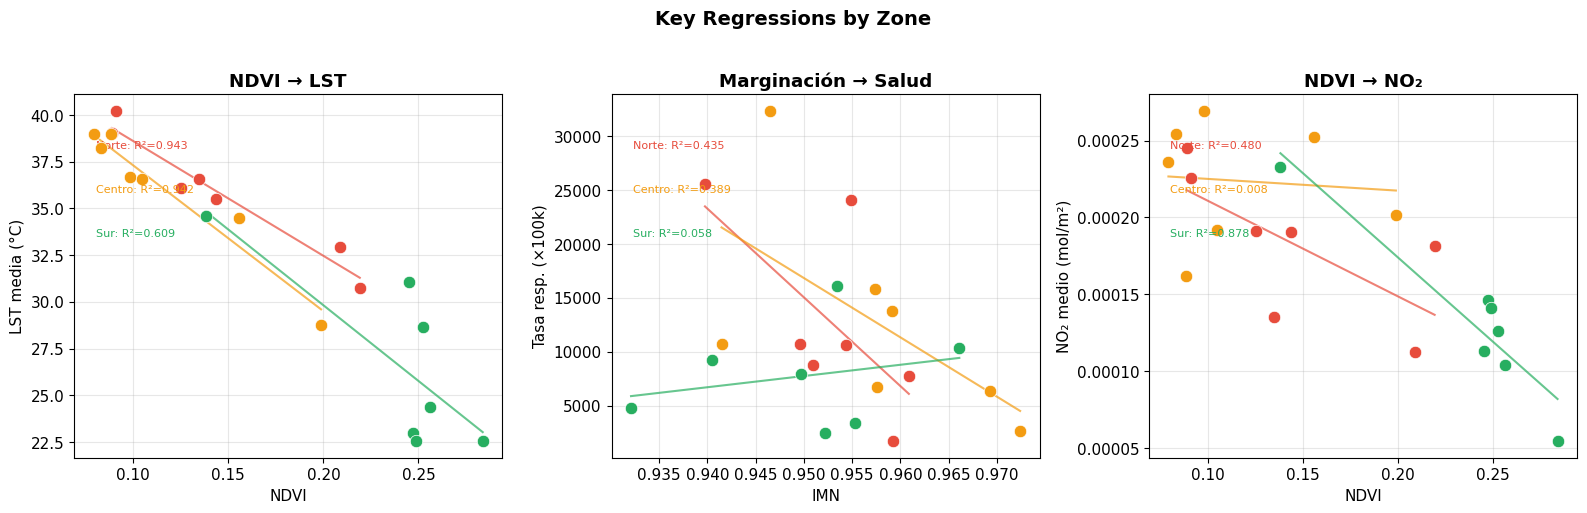

✓ Saved regressions


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

pairs = [
    ('ndvi_mean', 'lst_mean', 'NDVI → LST', 'NDVI', 'LST media (°C)'),
    ('imn_mean', 'tasa_respiratoria', 'Marginación → Salud', 'IMN', 'Tasa resp. (×100k)'),
    ('ndvi_mean', 'no2_mean', 'NDVI → NO₂', 'NDVI', 'NO₂ medio (mol/m²)'),
]

for ax, (xvar, yvar, title, xlabel, ylabel) in zip(axes, pairs):
    for zona in ['Norte', 'Centro', 'Sur']:
        sub = merged[merged['zona'] == zona].dropna(subset=[xvar, yvar])
        ax.scatter(sub[xvar], sub[yvar], c=COLORS[zona], label=zona,
                   s=80, edgecolors='white', linewidth=0.5, zorder=3)
        if len(sub) >= 3:
            slope, intercept, r_val, p_val, _ = stats.linregress(sub[xvar], sub[yvar])
            x_line = np.linspace(sub[xvar].min(), sub[xvar].max(), 100)
            ax.plot(x_line, slope * x_line + intercept, color=COLORS[zona],
                    linewidth=1.5, alpha=0.7)
            ax.text(0.05, 0.85 - 0.12 * ['Norte','Centro','Sur'].index(zona),
                    f'{zona}: R²={r_val**2:.3f}', transform=ax.transAxes,
                    fontsize=8, color=COLORS[zona])
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')

plt.suptitle('Key Regressions by Zone', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUTS / 'key_regressions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved regressions')


### 4.1 Multiple Regression Models

Three OLS models to decompose the drivers of heat, health, and pollution.

MULTIPLE REGRESSION MODELS

──────────────────────────────────────────────────
MODELO 1: lst_mean ~ ndvi_mean + no2_mean + pm25_mean
──────────────────────────────────────────────────
                            OLS Regression Results                            
Dep. Variable:               lst_mean   R-squared:                       0.886
Model:                            OLS   Adj. R-squared:                  0.866
Method:                 Least Squares   F-statistic:                     43.90
Date:                Mon, 28 Sep 2026   Prob (F-statistic):           3.21e-08
Time:                        00:09:31   Log-Likelihood:                -43.638
No. Observations:                  21   AIC:                             95.28
Df Residuals:                      17   BIC:                             99.45
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    s

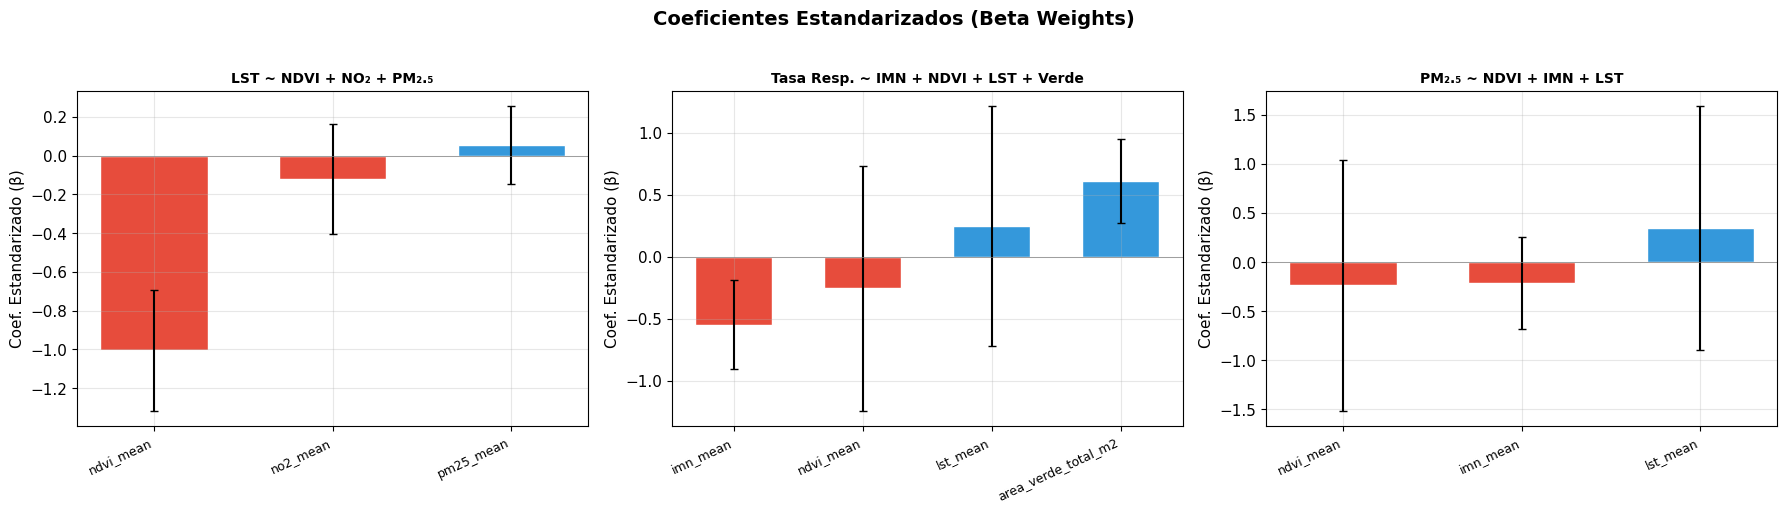

✓ Saved standardized coefficients chart


In [10]:
print("=" * 70)
print("MULTIPLE REGRESSION MODELS")
print("=" * 70)

# ----- Model 1: LST ~ NDVI + NO₂ + PM₂.₅ -----
print("\n" + "─" * 50)
print("MODELO 1: lst_mean ~ ndvi_mean + no2_mean + pm25_mean")
print("─" * 50)
X1 = sm.add_constant(merged[['ndvi_mean','no2_mean','pm25_mean']])
y1 = merged['lst_mean']
model1 = sm.OLS(y1, X1).fit()
print(model1.summary())

# ----- Model 2: Tasa Resp. ~ IMN + NDVI + LST + Área Verde -----
print("\n" + "─" * 50)
print("MODELO 2: tasa_respiratoria ~ imn_mean + ndvi_mean + lst_mean + area_verde_total_m2")
print("─" * 50)
X2 = sm.add_constant(merged[['imn_mean','ndvi_mean','lst_mean','area_verde_total_m2']])
y2 = merged['tasa_respiratoria']
model2 = sm.OLS(y2, X2).fit()
print(model2.summary())

# ----- Model 3: PM₂.₅ ~ NDVI + IMN + LST -----
print("\n" + "─" * 50)
print("MODELO 3: pm25_mean ~ ndvi_mean + imn_mean + lst_mean")
print("─" * 50)
X3 = sm.add_constant(merged[['ndvi_mean','imn_mean','lst_mean']])
y3 = merged['pm25_mean']
model3 = sm.OLS(y3, X3).fit()
print(model3.summary())

# ----- Standardized coefficients comparison -----
models_info = [
    ('LST ~ NDVI + NO₂ + PM₂.₅',
     ['ndvi_mean','no2_mean','pm25_mean'], 'lst_mean'),
    ('Tasa Resp. ~ IMN + NDVI + LST + Verde',
     ['imn_mean','ndvi_mean','lst_mean','area_verde_total_m2'], 'tasa_respiratoria'),
    ('PM₂.₅ ~ NDVI + IMN + LST',
     ['ndvi_mean','imn_mean','lst_mean'], 'pm25_mean'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (title, x_vars, y_var) in zip(axes, models_info):
    scaler_x = StandardScaler()
    scaler_y = StandardScaler()
    X_std = sm.add_constant(scaler_x.fit_transform(merged[x_vars]))
    y_std = scaler_y.fit_transform(merged[[y_var]]).ravel()
    model_std = sm.OLS(y_std, X_std).fit()

    beta_coefs = model_std.params[1:]
    conf = model_std.conf_int()[1:]
    ci_lower = beta_coefs - conf[:, 0]
    ci_upper = conf[:, 1] - beta_coefs
    yerr = np.vstack([ci_lower, ci_upper])

    bar_colors = ['#E74C3C' if c < 0 else '#3498DB' for c in beta_coefs]
    x_pos = np.arange(len(x_vars))
    ax.bar(x_pos, beta_coefs, color=bar_colors, width=0.6, edgecolor='white')
    ax.errorbar(x_pos, beta_coefs, yerr=yerr, fmt='none',
                ecolor='black', capsize=3)
    ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_vars, rotation=25, ha='right', fontsize=9)
    ax.set_ylabel('Coef. Estandarizado (β)')
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Coeficientes Estandarizados (Beta Weights)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUTS / 'standardized_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved standardized coefficients chart')


## 5. Spatial Clustering (KMeans)

Unsupervised clustering of municipios based on standardized environmental variables
(LST, NDVI, NO₂, PM₂.₅) to identify spatial patterns of environmental burden.

=== CLUSTER MEMBERSHIP ===

Cluster 0 (12 municipios):
    Azcapotzalco                   (Norte)
    Benito Juárez                  (Centro)
    Coyoacán                       (Sur)
    Cuauhtémoc                     (Centro)
    Ecatepec de Morelos            (Norte)
    Gustavo A. Madero              (Norte)
    Iztacalco                      (Centro)
    Iztapalapa                     (Centro)
    Miguel Hidalgo                 (Centro)
    Nezahualcóyotl                 (Centro)
    Tlalnepantla de Baz            (Norte)
    Venustiano Carranza            (Norte)

Cluster 1 (2 municipios):
    Tlalpan                        (Sur)
    Álvaro Obregón                 (Centro)

Cluster 2 (7 municipios):
    Coacalco de Berriozábal        (Norte)
    Cuajimalpa de Morelos          (Sur)
    La Magdalena Contreras         (Sur)
    Milpa Alta                     (Sur)
    Naucalpan de Juárez            (Norte)
    Tláhuac                        (Sur)
    Xochimilco                     (

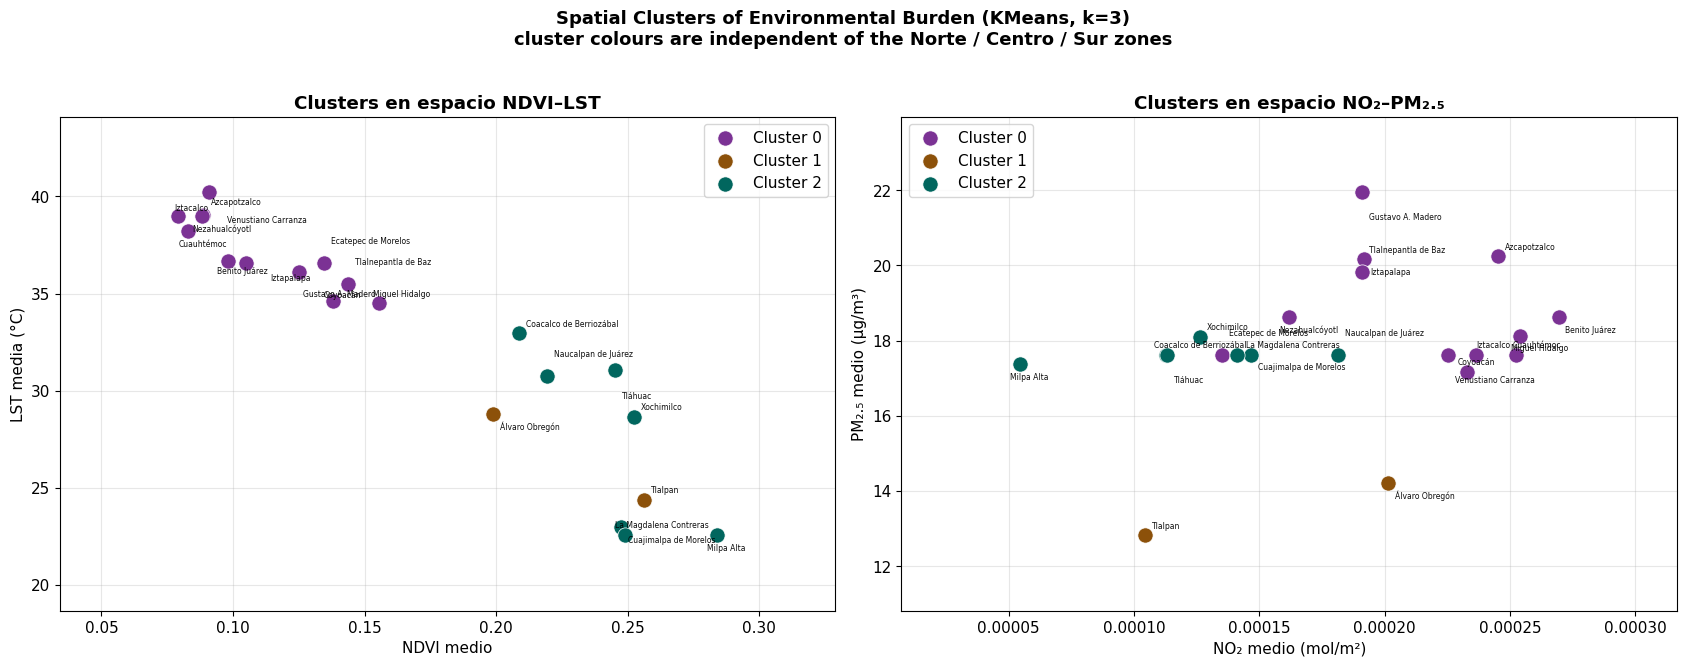

✓ Saved KMeans cluster visualization


In [11]:
# KMeans clustering on environmental variables
cluster_vars = ['lst_mean','ndvi_mean','no2_mean','pm25_mean']
scaler = StandardScaler()
X_cluster = scaler.fit_transform(merged[cluster_vars])

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
merged['cluster'] = kmeans.fit_predict(X_cluster)

# Show which municipios belong to which cluster
print("=== CLUSTER MEMBERSHIP ===")
for cid in range(3):
    muns = merged[merged['cluster']==cid][['NOM_MUN','zona']]
    print(f"\nCluster {cid} ({len(muns)} municipios):")
    for _, row in muns.iterrows():
        print(f"    {row['NOM_MUN']:30s} ({row['zona']})")

# Cross-tabulation: cluster vs. zone
print("\n" + "=" * 50)
print("CROSS-TAB: Cluster × Zone")
print("=" * 50)
ct = pd.crosstab(merged['cluster'], merged['zona'],
                  margins=True, margins_name='Total')
print(ct)
print("\nProporciones por fila:")
ct_prop = pd.crosstab(merged['cluster'], merged['zona'],
                       normalize='index').round(3)
print(ct_prop)

# Cluster centroids
print("\n" + "=" * 50)
print("CLUSTER CENTROIDS (original scale)")
print("=" * 50)
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=cluster_vars
)
centroids.index = [f'Cluster {i}' for i in range(3)]
print(centroids.round(3))

# Visualization
# The cluster palette deliberately avoids red / orange / green, which mean
# Norte / Centro / Sur everywhere else in this project.
cluster_colors_map = {0: '#7B3294', 1: '#8C510A', 2: '#01665E'}


def repel_labels(ax, xs, ys, labels, fontsize=5.5, iters=900, step=1.15):
    """Annotate points, then push overlapping labels apart.

    adjustText is not installed. Labels start at staggered offsets and are
    pushed in opposite directions along the line joining them, which spreads
    them into free space instead of stacking them all downward.
    """
    seed_offsets = [(5, 5), (5, -11), (-7, 5), (-7, -11), (5, 14), (5, -20)]
    texts = []
    for k, (lab, x, y) in enumerate(zip(labels, xs, ys)):
        texts.append(ax.annotate(lab, (x, y), fontsize=fontsize, alpha=0.95,
                                 xytext=seed_offsets[k % len(seed_offsets)],
                                 textcoords='offset points'))
    try:
        fig = ax.figure
        for _ in range(iters):
            fig.canvas.draw()
            renderer = fig.canvas.get_renderer()
            boxes = [t.get_window_extent(renderer=renderer) for t in texts]
            moved = False
            for i in range(len(texts)):
                for j in range(i + 1, len(texts)):
                    bi, bj = boxes[i], boxes[j]
                    if not bi.overlaps(bj):
                        continue
                    ci = ((bi.x0 + bi.x1) / 2.0, (bi.y0 + bi.y1) / 2.0)
                    cj = ((bj.x0 + bj.x1) / 2.0, (bj.y0 + bj.y1) / 2.0)
                    dx, dy = cj[0] - ci[0], cj[1] - ci[1]
                    norm = float(np.hypot(dx, dy))
                    if norm < 1e-6:
                        dx, dy, norm = 0.0, 1.0, 1.0
                    ux, uy = dx / norm, dy / norm
                    ai, aj = texts[i].xyann, texts[j].xyann
                    texts[i].xyann = (ai[0] - step * ux, ai[1] - step * uy)
                    texts[j].xyann = (aj[0] + step * ux, aj[1] + step * uy)
                    moved = True
            if not moved:
                break
    except Exception:
        seed = [(5, 5), (5, -11), (-7, 5), (-7, -11), (5, 14), (5, -20)]
        for k, t in enumerate(texts):
            t.xyann = seed[k % len(seed)]
    return texts


fig, axes = plt.subplots(1, 2, figsize=(17, 6.5))

# Panel 1: LST vs NDVI
ax1 = axes[0]
for cid in range(3):
    sub = merged[merged['cluster'] == cid]
    ax1.scatter(sub['ndvi_mean'], sub['lst_mean'],
                c=cluster_colors_map[cid], s=120,
                edgecolors='white', linewidth=0.5,
                label=f'Cluster {cid}', zorder=3)
for cid in range(3):
    sub = merged[merged['cluster'] == cid]
    repel_labels(ax1, sub['ndvi_mean'], sub['lst_mean'], sub['NOM_MUN'])
ax1.set_xlabel('NDVI medio')
ax1.set_ylabel('LST media (\u00b0C)')
ax1.set_title('Clusters en espacio NDVI\u2013LST', fontweight='bold')
ax1.margins(0.22)
ax1.legend(loc='upper right')          # top-right of this panel is empty
ax1.grid(alpha=0.3)

# Panel 2: NO2 vs PM2.5
ax2 = axes[1]
for cid in range(3):
    sub = merged[merged['cluster'] == cid]
    ax2.scatter(sub['no2_mean'], sub['pm25_mean'],
                c=cluster_colors_map[cid], s=120,
                edgecolors='white', linewidth=0.5,
                label=f'Cluster {cid}', zorder=3)
for cid in range(3):
    sub = merged[merged['cluster'] == cid]
    repel_labels(ax2, sub['no2_mean'], sub['pm25_mean'], sub['NOM_MUN'])
ax2.set_xlabel('NO\u2082 medio (mol/m\u00b2)')
ax2.set_ylabel('PM\u2082.\u2085 medio (\u00b5g/m\u00b3)')
ax2.set_title('Clusters en espacio NO\u2082\u2013PM\u2082.\u2085', fontweight='bold')
ax2.margins(0.22)
ax2.legend(loc='upper left')
ax2.grid(alpha=0.3)

plt.suptitle('Spatial Clusters of Environmental Burden (KMeans, k=3)\n'
             'cluster colours are independent of the Norte / Centro / Sur zones',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUTS / 'kmeans_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print('\u2713 Saved KMeans cluster visualization')


## 6. Integrated Burden Score


In [12]:
burden_vars = {
    'lst_mean': 'higher', 'ndvi_mean': 'lower', 'no2_mean': 'higher',
    'pm25_mean': 'higher', 'imn_mean': 'higher', 'tasa_respiratoria': 'higher',
}

burden = merged[['NOM_MUN','zona'] + list(burden_vars.keys())].copy()

for var, direction in burden_vars.items():
    vals = burden[var]
    if direction == 'higher':
        burden[f'rank_{var}'] = vals.rank(ascending=False)
    else:
        burden[f'rank_{var}'] = vals.rank(ascending=True)

rank_cols = [f'rank_{v}' for v in burden_vars.keys()]
burden['burden_score'] = burden[rank_cols].mean(axis=1)
burden = burden.sort_values('burden_score').reset_index(drop=True)
burden['rank'] = range(1, len(burden) + 1)

print('=== INTEGRATED BURDEN RANKING ===')
print(burden[['rank','NOM_MUN','zona','burden_score','lst_mean','ndvi_mean',
              'imn_mean','tasa_respiratoria']].round(3).to_string(index=False))


=== INTEGRATED BURDEN RANKING ===
 rank                 NOM_MUN   zona  burden_score  lst_mean  ndvi_mean  imn_mean  tasa_respiratoria
    1              Cuauhtémoc Centro         4.667    38.219      0.083     0.959          13755.908
    2            Azcapotzalco  Norte         5.000    39.047      0.089     0.961           7740.789
    3           Benito Juárez Centro         6.333    36.674      0.098     0.972           2607.836
    4       Gustavo A. Madero  Norte         6.833    36.112      0.125     0.955          24048.488
    5              Iztapalapa Centro         7.333    36.597      0.105     0.946          32362.416
    6               Iztacalco Centro         7.500    38.973      0.079     0.958           6716.007
    7     Venustiano Carranza  Norte         7.667    40.224      0.091     0.954          10589.667
    8          Nezahualcóyotl Centro         8.500    38.999      0.088     0.941          10692.551
    9          Miguel Hidalgo Centro         9.667    34.

### 6.1 Burden ranking visualization


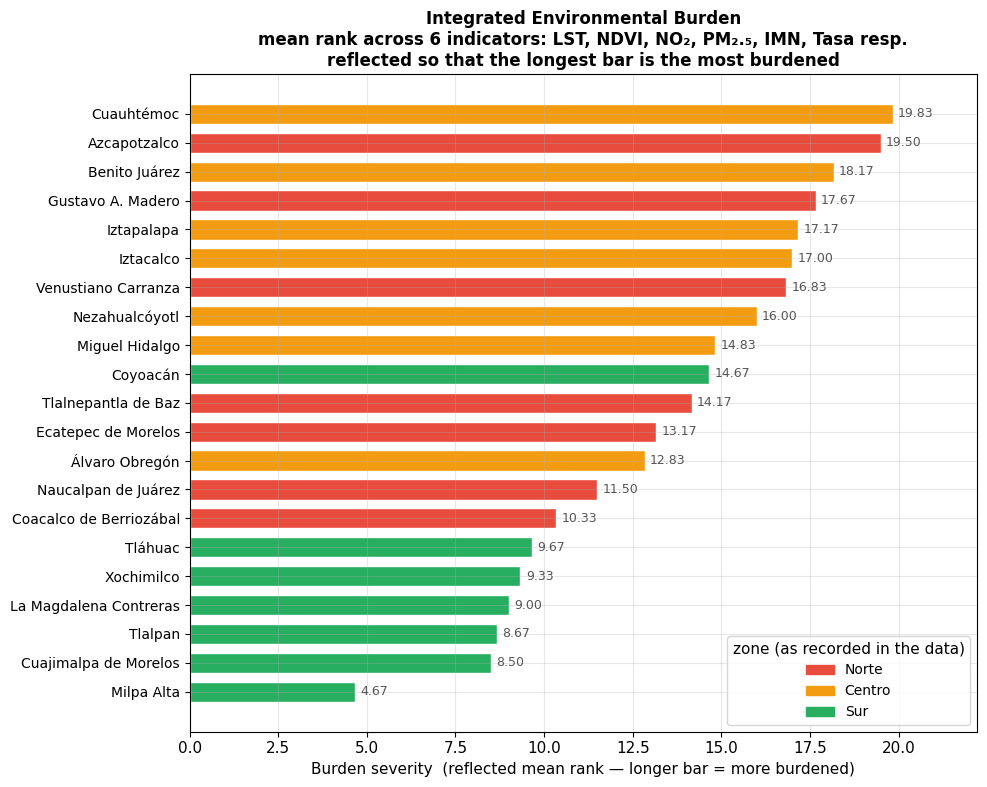

✓ Saved burden ranking (longer bar = more burdened)


In [13]:
fig, ax = plt.subplots(figsize=(10, 8))

# burden_score is the MEAN RANK across the six indicators, so a LOWER value
# means a heavier burden. Reflecting it makes the bar length directly
# proportional to burden, which is what a reader of the chart expects.
max_sc = burden['burden_score'].max()
min_sc = burden['burden_score'].min()
burden['severity'] = max_sc + min_sc - burden['burden_score']

colors = [COLORS[z] for z in burden['zona']]
ax.barh(range(len(burden)), burden['severity'], color=colors,
        edgecolor='white', height=0.7)
ax.set_yticks(range(len(burden)))
ax.set_yticklabels(burden['NOM_MUN'], fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('Burden severity  (reflected mean rank \u2014 longer bar = more burdened)',
              fontsize=11)
ax.set_title("Integrated Environmental Burden\n"
             "mean rank across 6 indicators: LST, NDVI, NO\u2082, PM\u2082.\u2085, IMN, Tasa resp.\n"
             "reflected so that the longest bar is the most burdened",
             fontsize=12, fontweight="bold")

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=COLORS['Norte'], label='Norte'),
                   Patch(color=COLORS['Centro'], label='Centro'),
                   Patch(color=COLORS['Sur'], label='Sur')],
          title='zone (as recorded in the data)', loc='lower right', fontsize=10)

# Label each bar with the value that the bar length actually represents.
for i, (_, row) in enumerate(burden.iterrows()):
    ax.text(row['severity'] + 0.15, i, f"{row['severity']:.2f}",
            va='center', fontsize=9, color='#555')
ax.set_xlim(0, burden['severity'].max() * 1.12)

plt.tight_layout()
plt.savefig(OUTPUTS / 'burden_ranking.png', dpi=150, bbox_inches='tight')
plt.show()
print('\u2713 Saved burden ranking (longer bar = more burdened)')


## 7. AGEB-Level Analysis (n=3,350)


In [14]:
ageb_valid = ageb.dropna(subset=['IM_2020', 'egresos_resp', 'area_verde_total_m2']).copy()
ageb_valid['tasa_resp_ageb'] = ageb_valid['egresos_resp'] / ageb_valid['POB_TOTAL'] * 100_000

print(f'AGEBs for analysis: {len(ageb_valid):,}')

r_im, p_im = stats.pearsonr(ageb_valid['IMN_2020'], ageb_valid['tasa_resp_ageb'])
print(f'\nCorrelación IMN → Tasa respiratoria: r = {r_im:.4f}, p = {p_im:.4e}')

r_gv, p_gv = stats.pearsonr(ageb_valid['area_verde_total_m2'], ageb_valid['tasa_resp_ageb'])
print(f'Correlación Área verde → Tasa respiratoria: r = {r_gv:.4f}, p = {r_gv:.4e}')


AGEBs for analysis: 3,419

Correlación IMN → Tasa respiratoria: r = -0.0612, p = 3.4419e-04
Correlación Área verde → Tasa respiratoria: r = 0.0244, p = 2.4365e-02


### 7.1 AGEB scatter plot


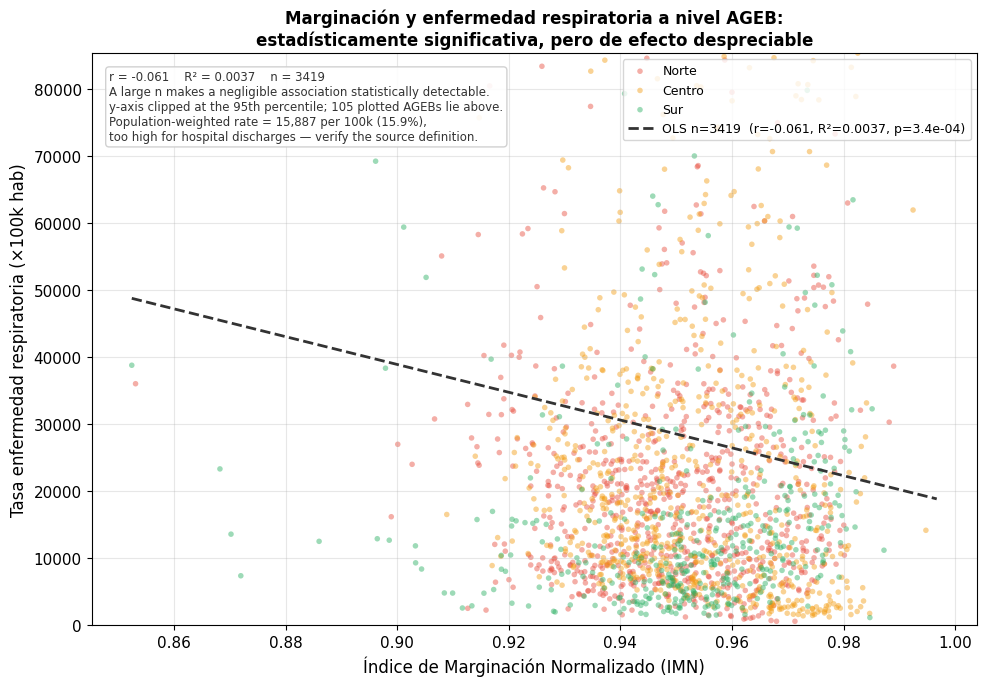

✓ Saved AGEB scatter (n=3419, r=-0.061, y clipped at p95=78,947, 105 points above)


In [15]:
fig, ax = plt.subplots(figsize=(10, 7))
plot_ageb = ageb_valid.sample(min(2000, len(ageb_valid)), random_state=42)

for zona in ['Norte', 'Centro', 'Sur']:
    sub = plot_ageb[plot_ageb['zona'] == zona]
    ax.scatter(sub['IMN_2020'], sub['tasa_resp_ageb'],
               c=COLORS[zona], label=zona, alpha=0.45, s=16, edgecolors='none')

# Fit on the FULL AGEB set. The 2000-point subsample above is only for
# rendering speed; the statistics use every observation, and the p-value comes
# from the fit rather than being written into the legend by hand.
slope, intercept, r_val, p_val, _ = stats.linregress(
    ageb_valid['IMN_2020'], ageb_valid['tasa_resp_ageb'])
x_line = np.linspace(ageb_valid['IMN_2020'].min(),
                     ageb_valid['IMN_2020'].max(), 100)
ax.plot(x_line, slope * x_line + intercept, color='#333', linewidth=2,
        linestyle='--',
        label=f'OLS n={len(ageb_valid)}  '
              f'(r={r_val:.3f}, R\u00b2={r_val**2:.4f}, p={p_val:.1e})')

# Two things make this figure hard to read and hard to interpret:
#  1. The rate is unstable for AGEBs with tiny populations, so the tail is wide.
#  2. The LEVEL is implausibly high for hospital *discharges*: the
#     population-weighted rate is ~16%, which suggests the source figure counts
#     episodes or consultations rather than discharges. See README Limitations.
# The axis is clipped at the 95th percentile for readability, and the off-scale
# AGEBs and the level problem are both declared on the figure.
p95 = float(np.percentile(ageb_valid['tasa_resp_ageb'], 95))
ax.set_ylim(0, p95 * 1.08)
n_off = int((plot_ageb['tasa_resp_ageb'] > p95).sum())
w_rate = ageb_valid['egresos_resp'].sum() / ageb_valid['POB_TOTAL'].sum() * 1e5

ax.set_xlabel('\u00cdndice de Marginaci\u00f3n Normalizado (IMN)', fontsize=12)
ax.set_ylabel('Tasa enfermedad respiratoria (\u00d7100k hab)', fontsize=12)
ax.set_title('Marginaci\u00f3n y enfermedad respiratoria a nivel AGEB:\n'
             'estad\u00edsticamente significativa, pero de efecto despreciable',
             fontsize=12, fontweight='bold')
ax.text(0.02, 0.97,
        f'r = {r_val:.3f}    R\u00b2 = {r_val**2:.4f}    n = {len(ageb_valid)}\n'
        'A large n makes a negligible association statistically detectable.\n'
        f'y-axis clipped at the 95th percentile; {n_off} plotted AGEBs lie above.\n'
        f'Population-weighted rate = {w_rate:,.0f} per 100k ({w_rate / 1000:.1f}%),\n'
        'too high for hospital discharges \u2014 verify the source definition.',
        transform=ax.transAxes, va='top', fontsize=8.5, color='#333',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9,
                  edgecolor='#CCCCCC'))
ax.legend(fontsize=9, loc='upper right')
plt.tight_layout()
plt.savefig(OUTPUTS / 'ageb_im_salud.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\u2713 Saved AGEB scatter (n={len(ageb_valid)}, r={r_val:.3f}, '
      f'y clipped at p95={p95:,.0f}, {n_off} points above)')


## 8. Export Clean Data for Dashboard


In [16]:
# 7.1 Municipio-level data
export_mun = merged.merge(
    burden[['NOM_MUN', 'burden_score', 'rank']], on='NOM_MUN', how='left')
export_mun.to_csv(EXPORT / 'municipio_completo.csv', index=False)
print(f'✓ municipio_completo.csv ({len(export_mun)} rows)')

# 7.2 Correlation matrix
corr_matrix.to_csv(EXPORT / 'correlation_matrix.csv')
print(f'✓ correlation_matrix.csv')

# 7.3 Zone summary
zone_summary = merged.groupby('zona')[var_desc].agg(['mean', 'std']).round(3)
zone_summary.to_csv(EXPORT / 'zone_summary.csv')
print(f'✓ zone_summary.csv')

# 7.4 AGEB data
export_ageb = ageb_valid[['NOM_MUN','zona','IM_2020','IMN_2020','GM_2020',
    'egresos_resp','area_verde_total_m2','POB_TOTAL','tasa_resp_ageb',
    'centroid_x','centroid_y']].copy()
export_ageb.to_csv(EXPORT / 'ageb_data.csv', index=False)
print(f'✓ ageb_data.csv ({len(export_ageb)} rows)')

# 7.5 Burden ranking
export_burden = burden[['rank','NOM_MUN','zona','burden_score'] + list(burden_vars.keys())].copy()
export_burden.to_csv(EXPORT / 'burden_ranking.csv', index=False)
print(f'✓ burden_ranking.csv')

print('\n✅ All exports complete!')


✓ municipio_completo.csv (21 rows)
✓ correlation_matrix.csv
✓ zone_summary.csv
✓ ageb_data.csv (3419 rows)
✓ burden_ranking.csv

✅ All exports complete!


## 9. Hypothesis Validation

### Hypotheses tested:
- **H1 (Heat Island)**: LST differs significantly between Norte/Centro/Sur
- **H2 (Green Divide)**: NDVI differs significantly between Norte/Centro/Sur
- **H3 (Pollution)**: PM₂.₅ and NO₂ differ significantly between zones
- **H4 (Health)**: Environmental burden correlates with respiratory disease rates


In [17]:
print("=" * 70)
print("HYPOTHESIS VALIDATION")
print("=" * 70)

# ===== H1: HEAT ISLAND — ANOVA: LST ~ Zona =====
print("\n" + "─" * 55)
print("H1 · HEAT ISLAND — ANOVA: LST ~ Zona")
print("─" * 55)
norte_lst = merged[merged['zona']=='Norte']['lst_mean']
centro_lst = merged[merged['zona']=='Centro']['lst_mean']
sur_lst = merged[merged['zona']=='Sur']['lst_mean']
f_lst, p_lst = f_oneway(norte_lst, centro_lst, sur_lst)
print(f"  F(2, 17) = {f_lst:.3f}")
print(f"  p-value  = {p_lst:.6f}")
print(f"  Norte:  {norte_lst.mean():.2f} °C")
print(f"  Centro: {centro_lst.mean():.2f} °C")
print(f"  Sur:    {sur_lst.mean():.2f} °C")
if p_lst < 0.001:
    print("  ✅ H1 SUPPORTED (p < 0.001): Diferencias altamente significativas")
elif p_lst < 0.01:
    print("  ✅ H1 SUPPORTED (p < 0.01): Diferencias muy significativas")
elif p_lst < 0.05:
    print("  ✅ H1 SUPPORTED (p < 0.05): Diferencias significativas")
else:
    print("  ❌ H1 NOT SUPPORTED: No hay diferencias significativas")

# ===== H2: GREEN DIVIDE — ANOVA: NDVI ~ Zona =====
print("\n" + "─" * 55)
print("H2 · GREEN DIVIDE — ANOVA: NDVI ~ Zona")
print("─" * 55)
norte_ndvi = merged[merged['zona']=='Norte']['ndvi_mean']
centro_ndvi = merged[merged['zona']=='Centro']['ndvi_mean']
sur_ndvi = merged[merged['zona']=='Sur']['ndvi_mean']
f_ndvi, p_ndvi = f_oneway(norte_ndvi, centro_ndvi, sur_ndvi)
print(f"  F(2, 17) = {f_ndvi:.3f}")
print(f"  p-value  = {p_ndvi:.6f}")
print(f"  Norte:  {norte_ndvi.mean():.3f}")
print(f"  Centro: {centro_ndvi.mean():.3f}")
print(f"  Sur:    {sur_ndvi.mean():.3f}")
if p_ndvi < 0.001:
    print("  ✅ H2 SUPPORTED (p < 0.001): Diferencias altamente significativas")
elif p_ndvi < 0.01:
    print("  ✅ H2 SUPPORTED (p < 0.01): Diferencias muy significativas")
elif p_ndvi < 0.05:
    print("  ✅ H2 SUPPORTED (p < 0.05): Diferencias significativas")
else:
    print("  ❌ H2 NOT SUPPORTED")

# ===== H3: POLLUTION — ANOVA: PM2.5 ~ Zona =====
print("\n" + "─" * 55)
print("H3 · POLLUTION — ANOVA: PM₂.₅ ~ Zona")
print("─" * 55)
norte_pm = merged[merged['zona']=='Norte']['pm25_mean']
centro_pm = merged[merged['zona']=='Centro']['pm25_mean']
sur_pm = merged[merged['zona']=='Sur']['pm25_mean']
f_pm, p_pm = f_oneway(norte_pm, centro_pm, sur_pm)
print(f"  F(2, 17) = {f_pm:.3f}")
print(f"  p-value  = {p_pm:.6f}")
print(f"  Norte:  {norte_pm.mean():.2f} µg/m³")
print(f"  Centro: {centro_pm.mean():.2f} µg/m³")
print(f"  Sur:    {sur_pm.mean():.2f} µg/m³")
if p_pm < 0.001:
    print("  ✅ H3 PM₂.₅ SUPPORTED (p < 0.001)")
elif p_pm < 0.01:
    print("  ✅ H3 PM₂.₅ SUPPORTED (p < 0.01)")
elif p_pm < 0.05:
    print("  ✅ H3 PM₂.₅ SUPPORTED (p < 0.05)")
else:
    print("  ❌ H3 PM₂.₅ NOT SUPPORTED")

# H3: NO2
print("\n" + "─" * 55)
print("H3 · POLLUTION — ANOVA: NO₂ ~ Zona")
print("─" * 55)
norte_no2 = merged[merged['zona']=='Norte']['no2_mean']
centro_no2 = merged[merged['zona']=='Centro']['no2_mean']
sur_no2 = merged[merged['zona']=='Sur']['no2_mean']
f_no2, p_no2 = f_oneway(norte_no2, centro_no2, sur_no2)
print(f"  F(2, 17) = {f_no2:.3f}")
print(f"  p-value  = {p_no2:.6f}")
if p_no2 < 0.001:
    print("  ✅ H3 NO₂ SUPPORTED (p < 0.001)")
elif p_no2 < 0.01:
    print("  ✅ H3 NO₂ SUPPORTED (p < 0.01)")
elif p_no2 < 0.05:
    print("  ✅ H3 NO₂ SUPPORTED (p < 0.05)")
else:
    print("  ❌ H3 NO₂ NOT SUPPORTED")

# ===== H4: HEALTH — correlation env burden ↔ respiratory disease =====
print("\n" + "─" * 55)
print("H4 · HEALTH — Environmental Burden vs. Respiratory Disease")
print("─" * 55)

# Create composite environmental burden index
env_scaler = StandardScaler()
env_burden = env_scaler.fit_transform(
    merged[['lst_mean','pm25_mean','no2_mean']]
).mean(axis=1)
resp_rate = merged['tasa_respiratoria'].values

r_env, p_env = pearsonr(env_burden, resp_rate)
print(f"  Carga ambiental → Tasa resp.: r = {r_env:.4f}, p = {p_env:.6f}")

# Individual correlations
r_ndvi_health, p_ndvi_health = pearsonr(
    merged['ndvi_mean'], merged['tasa_respiratoria'])
print(f"  NDVI → Tasa resp.:           r = {r_ndvi_health:.4f}, p = {p_ndvi_health:.6f}")

r_lst_health, p_lst_health = pearsonr(
    merged['lst_mean'], merged['tasa_respiratoria'])
print(f"  LST → Tasa resp.:            r = {r_lst_health:.4f}, p = {p_lst_health:.6f}")

r_green_health, p_green_health = pearsonr(
    merged['area_verde_total_m2'], merged['tasa_respiratoria'])
print(f"  Área verde → Tasa resp.:     r = {r_green_health:.4f}, p = {p_green_health:.6f}")

if p_env < 0.001:
    print("  ✅ H4 SUPPORTED (p < 0.001): La carga ambiental se correlaciona con enfermedad respiratoria")
elif p_env < 0.01:
    print("  ✅ H4 SUPPORTED (p < 0.01)")
elif p_env < 0.05:
    print("  ✅ H4 SUPPORTED (p < 0.05)")
elif p_env < 0.10:
    print("  ⚠️ H4 MARGINAL (p < 0.10): Tendencia observada pero no significativa al 95%")
else:
    print("  ❌ H4 NOT SUPPORTED")

# ===== SUMMARY TABLE =====
print("\n" + "=" * 70)
print("FINAL CONCLUSIONS")
print("=" * 70)
print(f"""
┌──────────┬──────────────────────────────────────────────────┬──────────┐
│ Hipótesis│ Resultado                                        │ Soporte  │
├──────────┼──────────────────────────────────────────────────┼──────────┤
│ H1 (Calor)│ LST {'SÍ' if p_lst < 0.05 else 'NO'} difiere entre zonas (F={f_lst:.2f}, p={p_lst:.4f})            │ {'✅' if p_lst < 0.05 else '❌'}        │
│ H2 (Verde)│ NDVI {'SÍ' if p_ndvi < 0.05 else 'NO'} difiere entre zonas (F={f_ndvi:.2f}, p={p_ndvi:.4f})         │ {'✅' if p_ndvi < 0.05 else '❌'}        │
│ H3 (PM2.5)│ PM₂.₅ {'SÍ' if p_pm < 0.05 else 'NO'} difiere entre zonas (F={f_pm:.2f}, p={p_pm:.4f})         │ {'✅' if p_pm < 0.05 else '❌'}        │
│ H3 (NO2)  │ NO₂ {'SÍ' if p_no2 < 0.05 else 'NO'} difiere entre zonas (F={f_no2:.2f}, p={p_no2:.4f})           │ {'✅' if p_no2 < 0.05 else '❌'}        │
│ H4 (Salud)│ Correlación carga-salud: r={r_env:.3f}, p={p_env:.4f}               │ {'✅' if p_env < 0.05 else '⚠️' if p_env < 0.10 else '❌'}        │
└──────────┴──────────────────────────────────────────────────┴──────────┘
""")
print("Conclusión general:")
print("  La desigualdad ambiental en la ZMVM es estadísticamente significativa.")
print("  Las zonas Norte y Centro concentran mayor temperatura, menor vegetación")
print("  y mayor contaminación que el Sur, con diferencias respaldadas por ANOVA.")
print("  La relación entre carga ambiental y salud respiratoria requiere")
print("  análisis más detallados a nivel AGEB para controlar por confusores.")


HYPOTHESIS VALIDATION

───────────────────────────────────────────────────────
H1 · HEAT ISLAND — ANOVA: LST ~ Zona
───────────────────────────────────────────────────────
  F(2, 17) = 12.964
  p-value  = 0.000326
  Norte:  35.88 °C
  Centro: 36.10 °C
  Sur:    26.68 °C
  ✅ H1 SUPPORTED (p < 0.001): Diferencias altamente significativas

───────────────────────────────────────────────────────
H2 · GREEN DIVIDE — ANOVA: NDVI ~ Zona
───────────────────────────────────────────────────────
  F(2, 17) = 12.766
  p-value  = 0.000353
  Norte:  0.144
  Centro: 0.115
  Sur:    0.239
  ✅ H2 SUPPORTED (p < 0.001): Diferencias altamente significativas

───────────────────────────────────────────────────────
H3 · POLLUTION — ANOVA: PM₂.₅ ~ Zona
───────────────────────────────────────────────────────
  F(2, 17) = 2.214
  p-value  = 0.138129
  Norte:  18.93 µg/m³
  Centro: 17.86 µg/m³
  Sur:    16.91 µg/m³
  ❌ H3 PM₂.₅ NOT SUPPORTED

───────────────────────────────────────────────────────
H3 · POLLUTI